# DSA 210 — Introduction to Data Science
## Self-Tracking Longitudinal Analysis
### Notebook 02: Exploratory Data Analysis & Hypothesis Testing
**2025–2026 Spring Term**

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')

Libraries loaded.


## 1. Data

In [2]:
# ---- Real weekly data collected throughout the semester ----
# Semester started end of February
# Data collected up to Week 10 (May 2nd)
#
# Exam dates: April 5, 6 (week 7), April 19 (week 8)
# Enrichment: week_type derived from official academic calendar
# Exam weeks: ~5 hrs/day x 5 days = ~25 hrs study
# Regular weeks: ~2-3 hrs/day x ~4 days = ~10 hrs study
# Grades: ~40-50% range -> productivity_score reflects exam performance
# Motivation: consistently low (3-4), declining toward week 9-10 (2-3)
# Stress: baseline 5-6, spikes to 8-9 on exam weeks
data = {
    'week':       [1,    2,    3,    4,    5,    6,    7,        8,        9,    10   ],
    'week_type':  ['regular','regular','regular','regular','regular','regular','midterm','midterm','regular','regular'],
    'study_hours':[10,   10,   9,    10,   9,    10,   25,       25,       10,   9    ],
    'sleep_avg':  [7.2,  7.0,  7.1,  7.0,  7.2,  7.0,  6.0,      6.2,      7.0,  7.1  ],
    'stress_level':[5,   5,    5,    5,    5,    6,    9,        8,        6,    6    ],
    'motivation_level':[4, 4,  4,    3,    3,    3,    3,        3,        2,    2    ],
    'language_difficulty':[5, 5, 5,  5,    5,    5,    6,        6,        5,    5    ],
    'productivity_score':[58, 56, 57, 55,  54,   53,   43,       46,       52,   50   ]
}

df = pd.DataFrame(data)
print(f'Shape: {df.shape[0]} weeks x {df.shape[1]} variables')
df

Shape: 10 weeks x 8 variables


,week,week_type,study_hours,sleep_avg,stress_level,motivation_level,language_difficulty,productivity_score
0,1,regular,10,7.2,5,4,5,58
1,2,regular,10,7.0,5,4,5,56
2,3,regular,9,7.1,5,4,5,57
3,4,regular,10,7.0,5,3,5,55
4,5,regular,9,7.2,5,3,5,54
5,6,regular,10,7.0,6,3,5,53
6,7,midterm,25,6.0,9,3,6,43
7,8,midterm,25,6.2,8,3,6,46
8,9,regular,10,7.0,6,2,5,52
9,10,regular,9,7.1,6,2,5,50


## 2. Exploratory Data Analysis
### 2.1 Descriptive Statistics

In [3]:
numeric_cols = ['study_hours','sleep_avg','stress_level',
                'motivation_level','language_difficulty','productivity_score']
print('=== Descriptive Statistics ===')
print(df[numeric_cols].describe().round(2))
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Week Type Counts ===')
print(df['week_type'].value_counts())

=== Descriptive Statistics ===
       study_hours  sleep_avg  stress_level  motivation_level  \
count        10.00      10.00         10.00             10.00   
mean         12.70       6.88          6.00              3.10   
std           6.50       0.42          1.41              0.74   
min           9.00       6.00          5.00              2.00   
25%           9.25       7.00          5.00              3.00   
50%          10.00       7.00          5.50              3.00   
75%          10.00       7.10          6.00              3.75   
max          25.00       7.20          9.00              4.00   

       language_difficulty  productivity_score  
count                10.00               10.00  
mean                  5.20               52.40  
std                   0.42                4.84  
min                   5.00               43.00  
25%                   5.00               50.50  
50%                   5.00               53.50  
75%                   5.00              

### 2.2 Productivity Over Time

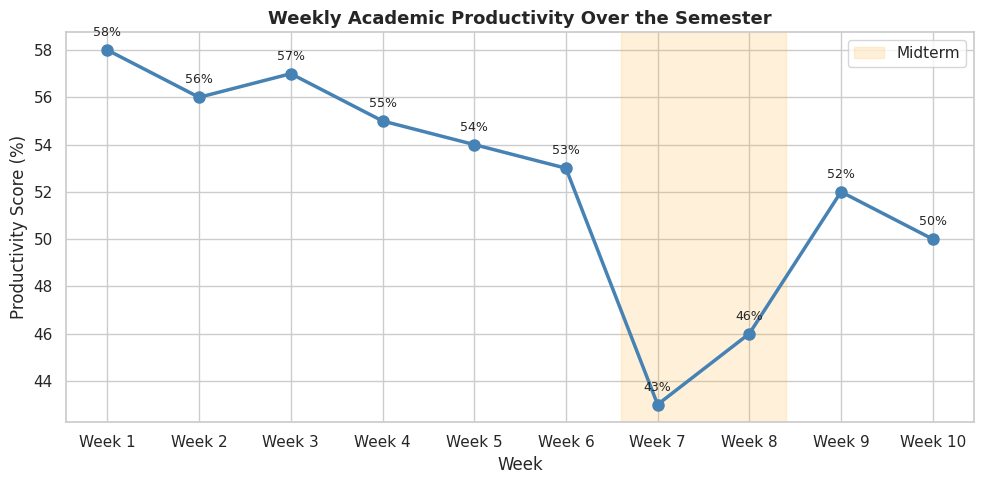

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['week'], df['productivity_score'], marker='o', color='steelblue', linewidth=2.5, markersize=8)
for _, row in df.iterrows():
    ax.annotate(f"{row['productivity_score']:.0f}%",
                xy=(row['week'], row['productivity_score']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)
midterm_weeks = df[df['week_type']=='midterm']['week']
if len(midterm_weeks):
    ax.axvspan(midterm_weeks.min()-0.4, midterm_weeks.max()+0.4, alpha=0.15, color='orange', label='Midterm')
ax.set_title('Weekly Academic Productivity Over the Semester', fontsize=13, fontweight='bold')
ax.set_xlabel('Week'); ax.set_ylabel('Productivity Score (%)')
ax.set_xticks(df['week']); ax.set_xticklabels([f'Week {w}' for w in df['week']])
ax.legend(); plt.tight_layout(); plt.show()

### 2.3 Productivity by Week Type

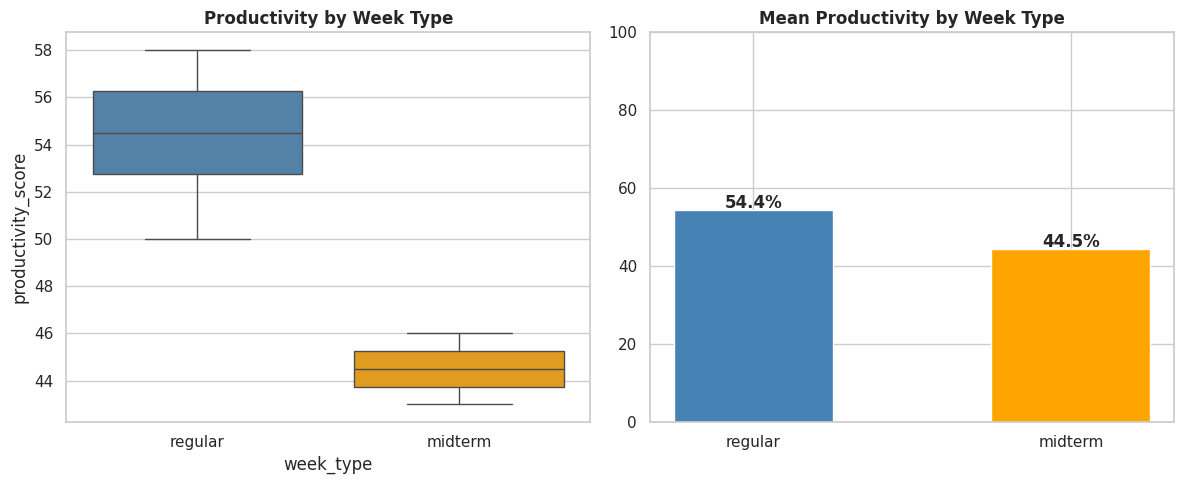

            mean   std  count
week_type                    
midterm    44.50  2.12      2
regular    54.38  2.67      8


In [5]:
palette = {'regular':'steelblue','midterm':'orange'}
order = ['regular','midterm']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='week_type', y='productivity_score', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Productivity by Week Type', fontweight='bold')
means = df.groupby('week_type')['productivity_score'].mean().reindex(order)
bars = axes[1].bar(means.index, means.values, color=[palette[w] for w in means.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Mean Productivity by Week Type', fontweight='bold'); axes[1].set_ylim(0, 100)
plt.tight_layout(); plt.show()
print(df.groupby('week_type')['productivity_score'].agg(['mean','std','count']).round(2))

### 2.4 Correlation Heatmap

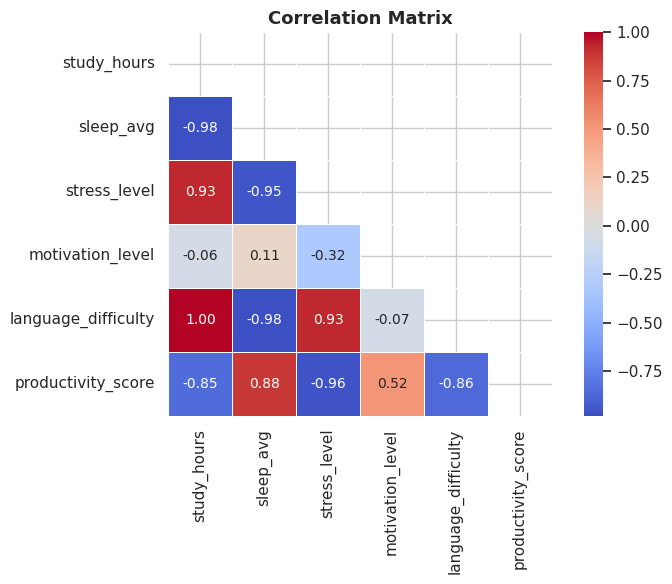

Correlations with Productivity Score:
sleep_avg              0.88
motivation_level       0.52
study_hours           -0.85
language_difficulty   -0.86
stress_level          -0.96
Name: productivity_score, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, mask=mask, ax=ax, fmt='.2f', annot_kws={'size':10})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Correlations with Productivity Score:')
print(corr['productivity_score'].drop('productivity_score').sort_values(ascending=False))

### 2.5 Scatter Plots: Predictors vs Productivity

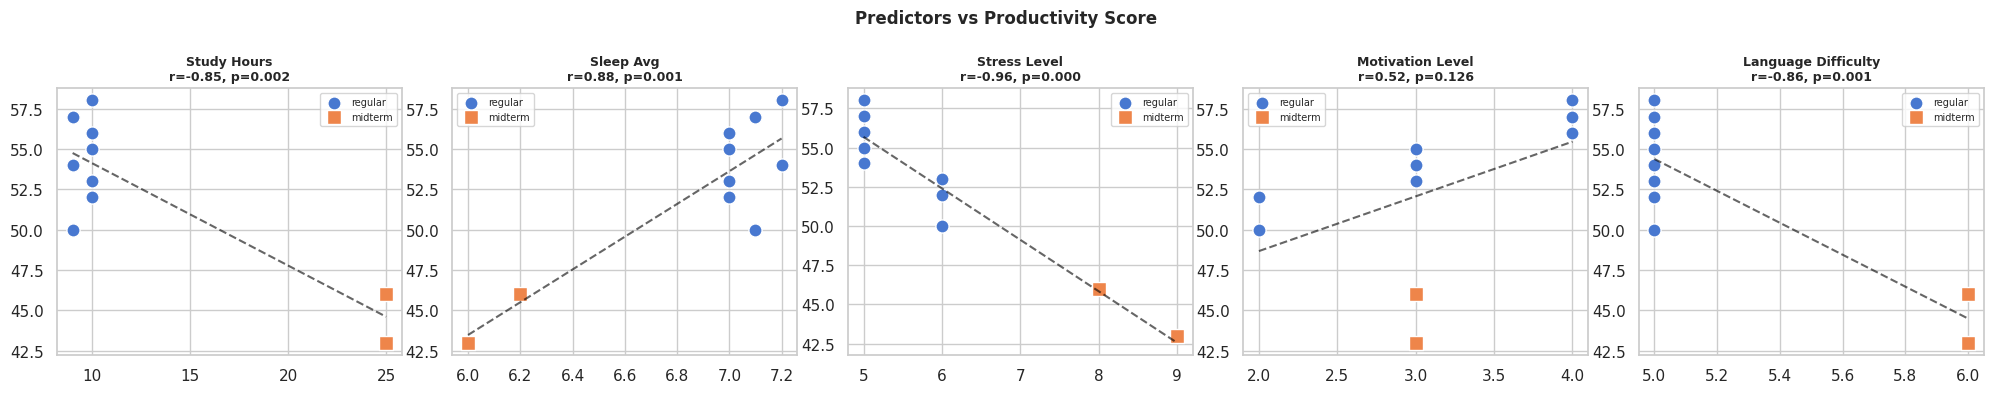

In [7]:
predictors = [('study_hours','steelblue'),('sleep_avg','seagreen'),
              ('stress_level','tomato'),('motivation_level','mediumpurple'),
              ('language_difficulty','darkorange')]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (col, color) in zip(axes, predictors):
    for wt, marker in [('regular','o'),('midterm','s')]:
        sub = df[df['week_type']==wt]
        ax.scatter(sub[col], sub['productivity_score'], label=wt, marker=marker, s=90, edgecolors='white')
    m, b = np.polyfit(df[col], df['productivity_score'], 1)
    x_l = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_l, m*x_l+b, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    r, p = stats.pearsonr(df[col], df['productivity_score'])
    ax.set_title(f'{col.replace("_"," ").title()}\nr={r:.2f}, p={p:.3f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
plt.suptitle('Predictors vs Productivity Score', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Hypothesis Testing
Significance level: **alpha = 0.05**

In [15]:
alpha = 0.05
def print_result(stat_name, stat_val, p_val, alpha=0.05):
    decision = 'REJECT H0 (significant)' if p_val < alpha else 'FAIL TO REJECT H0'
    print(f'  {stat_name}: {stat_val:.4f}')
    print(f'  p-value : {p_val:.4f}')
    print(f'  Result  : {decision}\n')

In [9]:
print('--- H1: Study Hours -> Productivity ---')
print('  H0: No correlation | H1: Positive')
r, p = stats.pearsonr(df['study_hours'], df['productivity_score'])
print_result('Pearson r', r, p)

--- H1: Study Hours -> Productivity ---
  H0: No correlation | H1: Positive
  Pearson r: -0.8515
  p-value : 0.0018
  Result  : REJECT H0 (significant)



In [10]:
print('--- H2: Sleep -> Productivity ---')
print('  H0: No correlation | H1: Positive')
r, p = stats.pearsonr(df['sleep_avg'], df['productivity_score'])
print_result('Pearson r', r, p)

--- H2: Sleep -> Productivity ---
  H0: No correlation | H1: Positive
  Pearson r: 0.8830
  p-value : 0.0007
  Result  : REJECT H0 (significant)



In [11]:
print('--- H3: Stress -> Productivity ---')
print('  H0: No correlation | H1: Negative')
r, p = stats.pearsonr(df['stress_level'], df['productivity_score'])
print_result('Pearson r', r, p)

--- H3: Stress -> Productivity ---
  H0: No correlation | H1: Negative
  Pearson r: -0.9587
  p-value : 0.0000
  Result  : REJECT H0 (significant)



In [12]:
print('--- H4: Week Type -> Productivity (t-test) ---')
print('  H0: Equal means | H1: Different means')
regular_prod = df[df['week_type']=='regular']['productivity_score']
midterm_prod  = df[df['week_type']=='midterm']['productivity_score']
t4, p4 = stats.ttest_ind(regular_prod, midterm_prod)
print_result('t-statistic', t4, p4)
print(f'  Regular mean: {regular_prod.mean():.2f}  |  Midterm mean: {midterm_prod.mean():.2f}')

--- H4: Week Type -> Productivity (t-test) ---
  H0: Equal means | H1: Different means
  t-statistic: 4.7912
  p-value : 0.0014
  Result  : REJECT H0 (significant)

  Regular mean: 54.38  |  Midterm mean: 44.50


In [13]:
print('--- H5: Motivation -> Productivity (Spearman) ---')
print('  H0: No relationship | H1: Positive')
r5, p5 = stats.spearmanr(df['motivation_level'], df['productivity_score'])
print_result('Spearman rho', r5, p5)

--- H5: Motivation -> Productivity (Spearman) ---
  H0: No relationship | H1: Positive
  Spearman rho: 0.7369
  p-value : 0.0150
  Result  : REJECT H0 (significant)



### 3.1 Summary Table

In [14]:
r1,p1 = stats.pearsonr(df['study_hours'], df['productivity_score'])
r2,p2 = stats.pearsonr(df['sleep_avg'], df['productivity_score'])
r3,p3 = stats.pearsonr(df['stress_level'], df['productivity_score'])
t4,p4 = stats.ttest_ind(df[df['week_type']=='regular']['productivity_score'],
                         df[df['week_type']=='midterm']['productivity_score'])
r5,p5 = stats.spearmanr(df['motivation_level'], df['productivity_score'])

summary = pd.DataFrame({
    'Hypothesis': ['H1: Study Hours','H2: Sleep','H3: Stress','H4: Week Type','H5: Motivation'],
    'Test': ['Pearson r','Pearson r','Pearson r','t-test','Spearman rho'],
    'Statistic': [round(r1,4),round(r2,4),round(r3,4),round(t4,4),round(r5,4)],
    'p-value':   [round(p1,4),round(p2,4),round(p3,4),round(p4,4),round(p5,4)],
    'Significant': ['Yes' if p<0.05 else 'No' for p in [p1,p2,p3,p4,p5]]
})
print(summary.to_string(index=False))

     Hypothesis         Test  Statistic  p-value Significant
H1: Study Hours    Pearson r    -0.8515   0.0018         Yes
      H2: Sleep    Pearson r     0.8830   0.0007         Yes
     H3: Stress    Pearson r    -0.9587   0.0000         Yes
  H4: Week Type       t-test     4.7912   0.0014         Yes
 H5: Motivation Spearman rho     0.7369   0.0150         Yes
